In [40]:
import sys
import os
sys.path.append(os.path.abspath("../"))

In [41]:
from utils.loaders import load_sweep
from utils.styles import apply
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

apply(context="paper", col="single")

In [42]:
save_path = "/Users/niaggar/Results"

radius_values = [0.020, 0.035, 0.055, 0.075, 0.100, 0.175]
N_REPLICAS = 5

data_names = []
for rep in range(N_REPLICAS):
    for index, rad in enumerate(radius_values):
        name = f"radius_{rad:.3f}__rep{rep}"
        val = index * N_REPLICAS + rep
        full_name = f"{val:04d}_{name}"
        data_names.append((full_name, rf"R={rad*1000:.0f} $\mu$m"))

print(data_names)


[('0000_radius_0.020__rep0', 'R=20 $\\mu$m'), ('0005_radius_0.035__rep0', 'R=35 $\\mu$m'), ('0010_radius_0.055__rep0', 'R=55 $\\mu$m'), ('0015_radius_0.075__rep0', 'R=75 $\\mu$m'), ('0020_radius_0.100__rep0', 'R=100 $\\mu$m'), ('0025_radius_0.175__rep0', 'R=175 $\\mu$m'), ('0001_radius_0.020__rep1', 'R=20 $\\mu$m'), ('0006_radius_0.035__rep1', 'R=35 $\\mu$m'), ('0011_radius_0.055__rep1', 'R=55 $\\mu$m'), ('0016_radius_0.075__rep1', 'R=75 $\\mu$m'), ('0021_radius_0.100__rep1', 'R=100 $\\mu$m'), ('0026_radius_0.175__rep1', 'R=175 $\\mu$m'), ('0002_radius_0.020__rep2', 'R=20 $\\mu$m'), ('0007_radius_0.035__rep2', 'R=35 $\\mu$m'), ('0012_radius_0.055__rep2', 'R=55 $\\mu$m'), ('0017_radius_0.075__rep2', 'R=75 $\\mu$m'), ('0022_radius_0.100__rep2', 'R=100 $\\mu$m'), ('0027_radius_0.175__rep2', 'R=175 $\\mu$m'), ('0003_radius_0.020__rep3', 'R=20 $\\mu$m'), ('0008_radius_0.035__rep3', 'R=35 $\\mu$m'), ('0013_radius_0.055__rep3', 'R=55 $\\mu$m'), ('0018_radius_0.075__rep3', 'R=75 $\\mu$m'), ('0

# Linear Polarization study of RGD particles

In [43]:
folder_cbs = "study_estimator_vs_analog"
sweep_cbs = load_sweep(folder_cbs, base_path=Path(save_path))

data_cbs_keys = list(sweep_cbs.keys())
data_cbs_keys = sorted(data_cbs_keys, key=lambda k: int(k[:4]))
estimator_cbs_keys = [key for key in data_cbs_keys if "estimator" in key]
analog_cbs_keys = [key for key in data_cbs_keys if "analog" in key]

print(f"Found {len(estimator_cbs_keys)} estimator datasets: {estimator_cbs_keys}")
print(f"Found {len(analog_cbs_keys)} analog datasets: {analog_cbs_keys}")


last_key_estimator = estimator_cbs_keys[-1]
last_key_analog = analog_cbs_keys[-1]


Found 5 estimator datasets: ['0000_radius_0.055_estimator_N1000_rep00', '0001_radius_0.055_estimator_N10000_rep00', '0002_radius_0.055_estimator_N30000_rep00', '0003_radius_0.055_estimator_N100000_rep00', '0004_radius_0.055_estimator_N300000_rep00']
Found 6 analog datasets: ['0000_radius_0.055_analog_N1000000000_rep00', '0005_radius_0.055_analog_N1000000_rep00', '0006_radius_0.055_analog_N10000000_rep00', '0007_radius_0.055_analog_N50000000_rep00', '0008_radius_0.055_analog_N100000000_rep00', '0009_radius_0.055_analog_N500000000_rep00']


In [44]:
def load_stitched(sweep, key, basis, reduce, channel, k, lstar):
    """Une det_1 (fino) y det_2 (cola) promediando la banda de solape.
    Devuelve theta [rad], q=k*lstar*theta, y el enhancement del canal."""
    p1 = cbs_profiles(sweep[key].processed_cbs("farfield_cbs_1"),
                      basis=basis, time_index=0, reduce=reduce)
    p2 = cbs_profiles(sweep[key].processed_cbs("farfield_cbs_2"),
                      basis=basis, time_index=0, reduce=reduce)
    th1, g1 = np.asarray(p1.theta), np.asarray(p1.enhancement[channel])
    th2, g2 = np.asarray(p2.theta), np.asarray(p2.enhancement[channel])

    theta_1 = th1[-1]                       # fin de la ventana fina
    lo = 0.9 * theta_1                       # inicio real de det_2 (solape)

    # --- chequeo de stitching: interpola det_1 sobre los bins de solape de det_2
    ov = (th2 >= lo) & (th2 <= theta_1)
    if ov.any():
        g1_on2 = np.interp(th2[ov], th1, g1)
        resid = np.abs(g2[ov] - g1_on2)
        if np.max(resid) > 0.05:            # umbral: 5% del enhancement
            print(f"[stitch WARN] {key} ch={channel}: max solape "
                  f"{np.max(resid):.3f} -- revisar normalizacion angulo solido")

    # une: det_1 completo + det_2 estrictamente por encima de theta_1
    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])
    q = k * lstar * theta
    return theta, q, g

[stitch WARN] 0005_radius_0.055_analog_N1000000_rep00 ch=co: max solape 0.387 -- revisar normalizacion angulo solido
[stitch WARN] 0005_radius_0.055_analog_N1000000_rep00 ch=cross: max solape 0.343 -- revisar normalizacion angulo solido
[stitch WARN] 0006_radius_0.055_analog_N10000000_rep00 ch=co: max solape 0.058 -- revisar normalizacion angulo solido
[stitch WARN] 0006_radius_0.055_analog_N10000000_rep00 ch=cross: max solape 0.098 -- revisar normalizacion angulo solido
[stitch WARN] 0007_radius_0.055_analog_N50000000_rep00 ch=cross: max solape 0.125 -- revisar normalizacion angulo solido
[stitch WARN] 0008_radius_0.055_analog_N100000000_rep00 ch=co: max solape 0.055 -- revisar normalizacion angulo solido


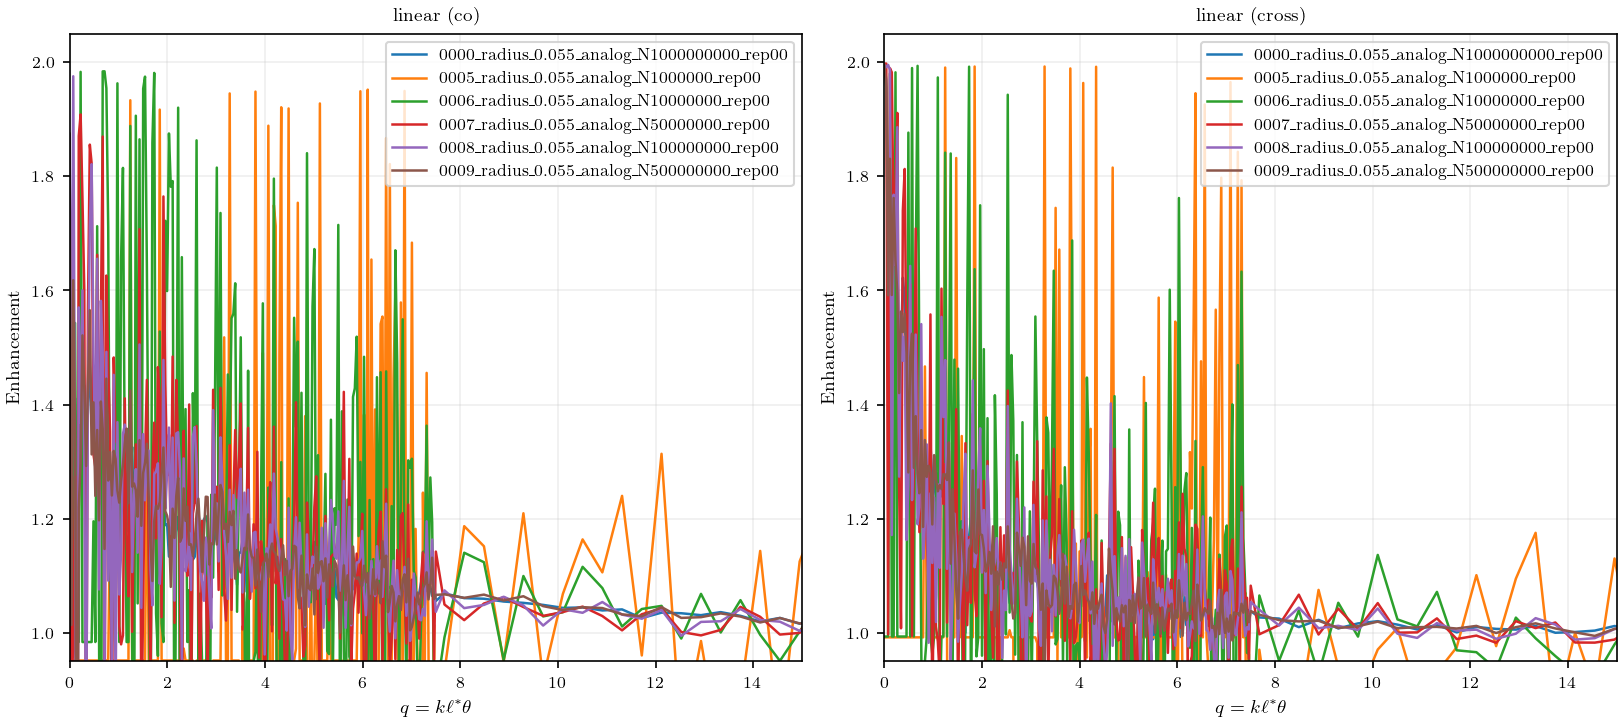

In [45]:
N_MEDIUM = 1.33
WAVELENGTH = 0.514
k = 2 * np.pi * N_MEDIUM / WAVELENGTH


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

for key in analog_cbs_keys:
    lstar = sweep_cbs[key].params_flat["transport_mean_free_path"]
    red = phi_cut(0)
    
    for ax, chan in [(ax1, "co"), (ax2, "cross")]:
        theta, q, g = load_stitched(sweep_cbs, key, circular, red, chan, k, lstar)
        base = np.median(g[q > 25])          # fondo medido en la cola (q grande)
        ax.plot(q, g - base + 1.0, label=key)   # baseline normalizada a 1

for ax, t in [(ax1, "co"), (ax2, "cross")]:
    ax.set_xlabel(r"$q = k\ell^*\theta$"); ax.set_ylabel("Enhancement")
    ax.set_xlim(0, 15); ax.set_ylim(0.95, 2.05); ax.grid(alpha=0.2)
    ax.legend(fontsize=8); ax.set_title(f"linear ({t})")
fig.tight_layout(); plt.show()

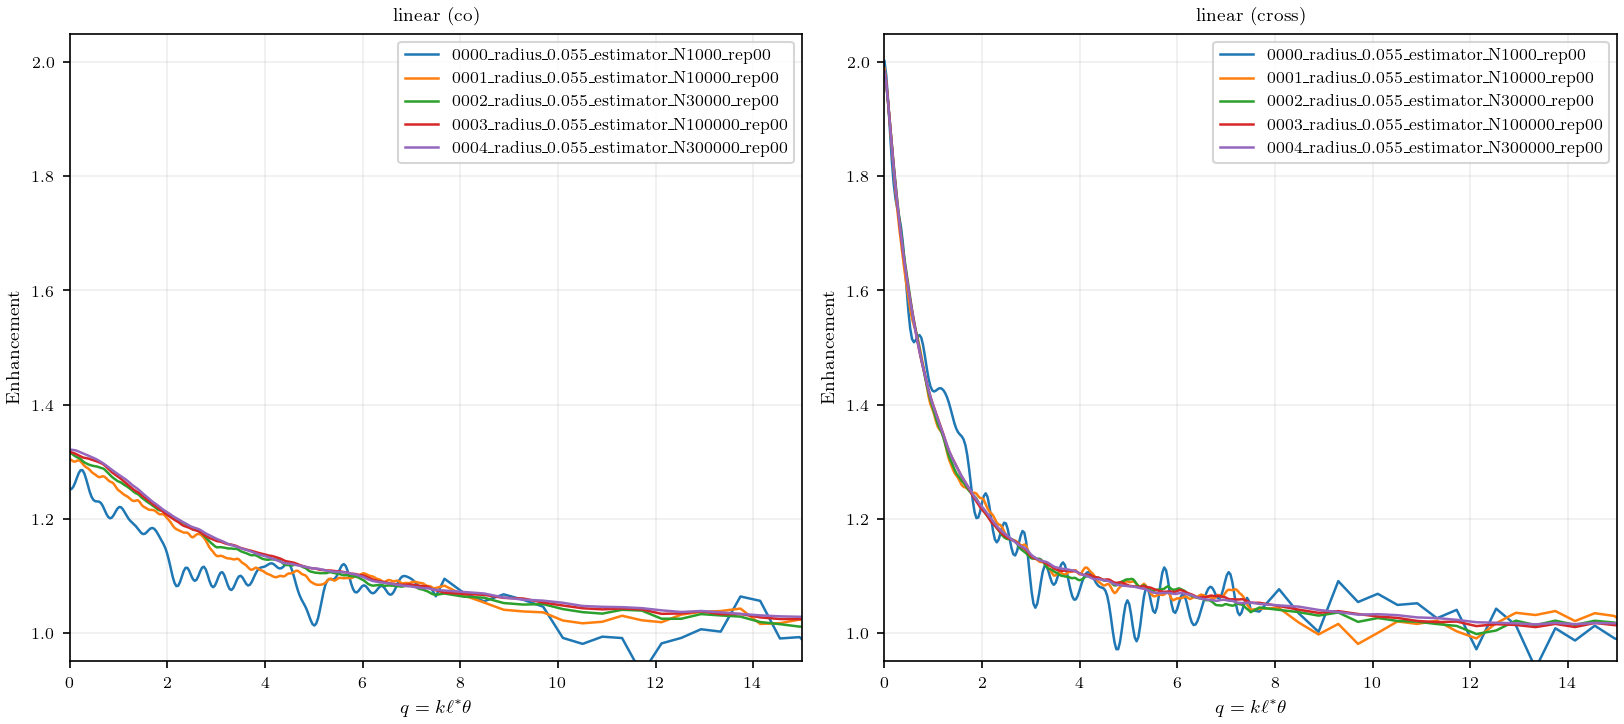

In [46]:
N_MEDIUM = 1.33
WAVELENGTH = 0.514
k = 2 * np.pi * N_MEDIUM / WAVELENGTH


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

for key in estimator_cbs_keys:
    lstar = sweep_cbs[key].params_flat["transport_mean_free_path"]
    red = phi_cut(0)
    
    for ax, chan in [(ax1, "co"), (ax2, "cross")]:
        theta, q, g = load_stitched(sweep_cbs, key, circular, red, chan, k, lstar)
        base = np.median(g[q > 25])          # fondo medido en la cola (q grande)
        ax.plot(q, g - base + 1.0, label=key)   # baseline normalizada a 1

for ax, t in [(ax1, "co"), (ax2, "cross")]:
    ax.set_xlabel(r"$q = k\ell^*\theta$"); ax.set_ylabel("Enhancement")
    ax.set_xlim(0, 15); ax.set_ylim(0.95, 2.05); ax.grid(alpha=0.2)
    ax.legend(fontsize=8); ax.set_title(f"linear ({t})")
fig.tight_layout(); plt.show()

In [47]:
folder_mix = "study_estimator_vs_analog_mix"
sweep_mix = load_sweep(folder_mix, base_path=Path(save_path))

key_estimator_layer = '0000_layers_z117.67_estimator_rep00'
key_estimator_mix = '0002_mixture_x0.50_estimator_rep00'

key_analog_layer = '0001_layers_z117.67_analog_rep00'
key_analog_mix = '0003_mixture_x0.50_analog_rep00'

In [59]:
BASIS = circular          # el mismo basis que ya pasas a load_stitched
BASIS_NAME = "circular"   # <- titulo; cambia a "linear" si esa fue la corrida
red = phi_cut(1)

def profile(sweep, key, chan, lstar):
    """Perfil apilado (fino+cola), baseline de la cola (q>25) llevada a 1."""
    _, q, g = load_stitched(sweep, key, BASIS, red, chan, k, lstar)
    return q, g - np.median(g[q > 25]) + 1.0

def plot_estimator_vs_analog(sweep, title, key_est, key_ana, lstar_key):
    le = sweep[key_est].params_flat[lstar_key]
    la = sweep[key_ana].params_flat[lstar_key]

    fig, ax = plt.subplots(2, 2, figsize=(11, 7), sharex=True,
                           gridspec_kw={"height_ratios": [3, 1]})
    for col, chan in enumerate(["co", "cross"]):
        qa, ga = profile(sweep, key_ana, chan, la)
        qe, ge = profile(sweep, key_est, chan, le)

        # arriba: analog (nube) + estimator (linea gruesa encima)
        ax[0, col].plot(qa, ga, color="orange", lw=0.6, alpha=0.7, label="Analog")
        ax[0, col].plot(qe, ge, color="C0", lw=1.8, label="Estimator")
        ax[0, col].set_ylim(0.95, 2.05); ax[0, col].set_ylabel("Enhancement")
        ax[0, col].grid(alpha=0.2); ax[0, col].legend(fontsize=8)
        ax[0, col].set_title(f"{BASIS_NAME} ({chan})")

        # abajo: residual (mismo grid via interp por si el stitch difiere un bin)
        resid = ge - np.interp(qe, qa, ga)
        cone = qe <= 8                          # cuantificar dentro del cono
        ax[1, col].axhline(0, color="k", lw=0.8)
        ax[1, col].plot(qe, resid, color="gray", lw=0.6)
        ax[1, col].set_ylim(-0.4, 0.4)
        ax[1, col].set_xlabel(r"$q = k\ell^*\theta$")
        ax[1, col].set_ylabel("Est $-$ Analog")
        ax[1, col].grid(alpha=0.2)
        ax[1, col].text(0.97, 0.92,
            f"media = {resid[cone].mean():+.3f}\nrms = {np.sqrt((resid[cone]**2).mean()):.3f}",
            transform=ax[1, col].transAxes, ha="right", va="top", fontsize=8)

    ax[0, 0].set_xlim(0, 15)
    fig.suptitle(title)
    fig.tight_layout(); plt.show()

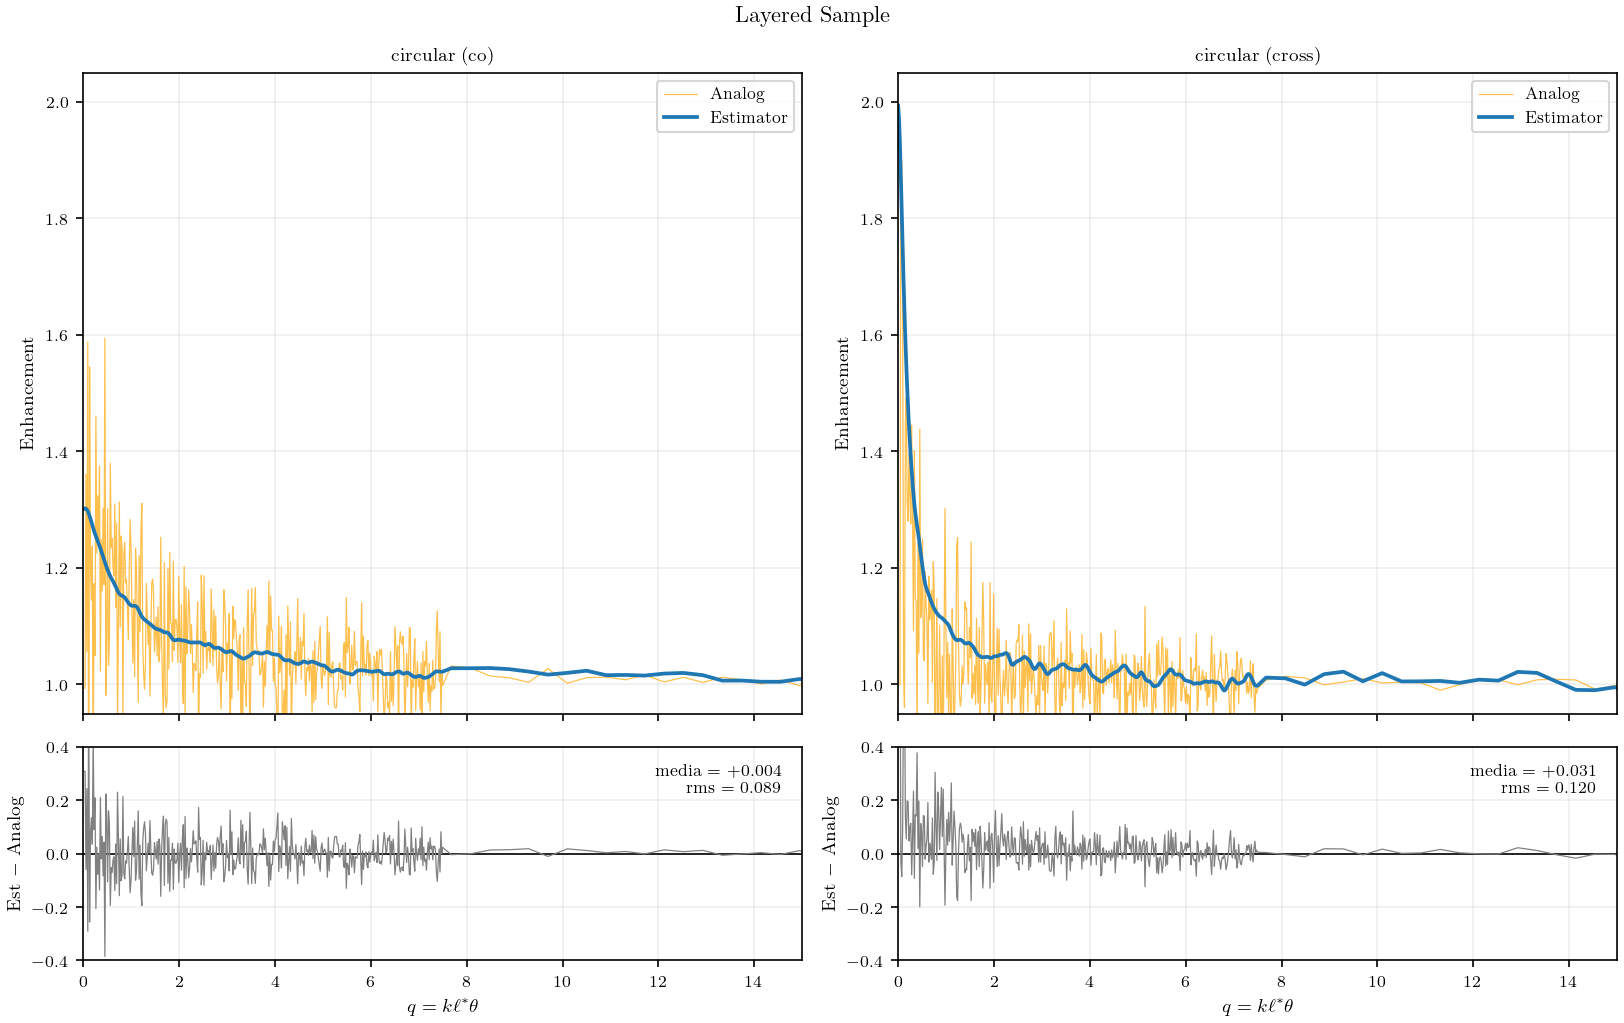

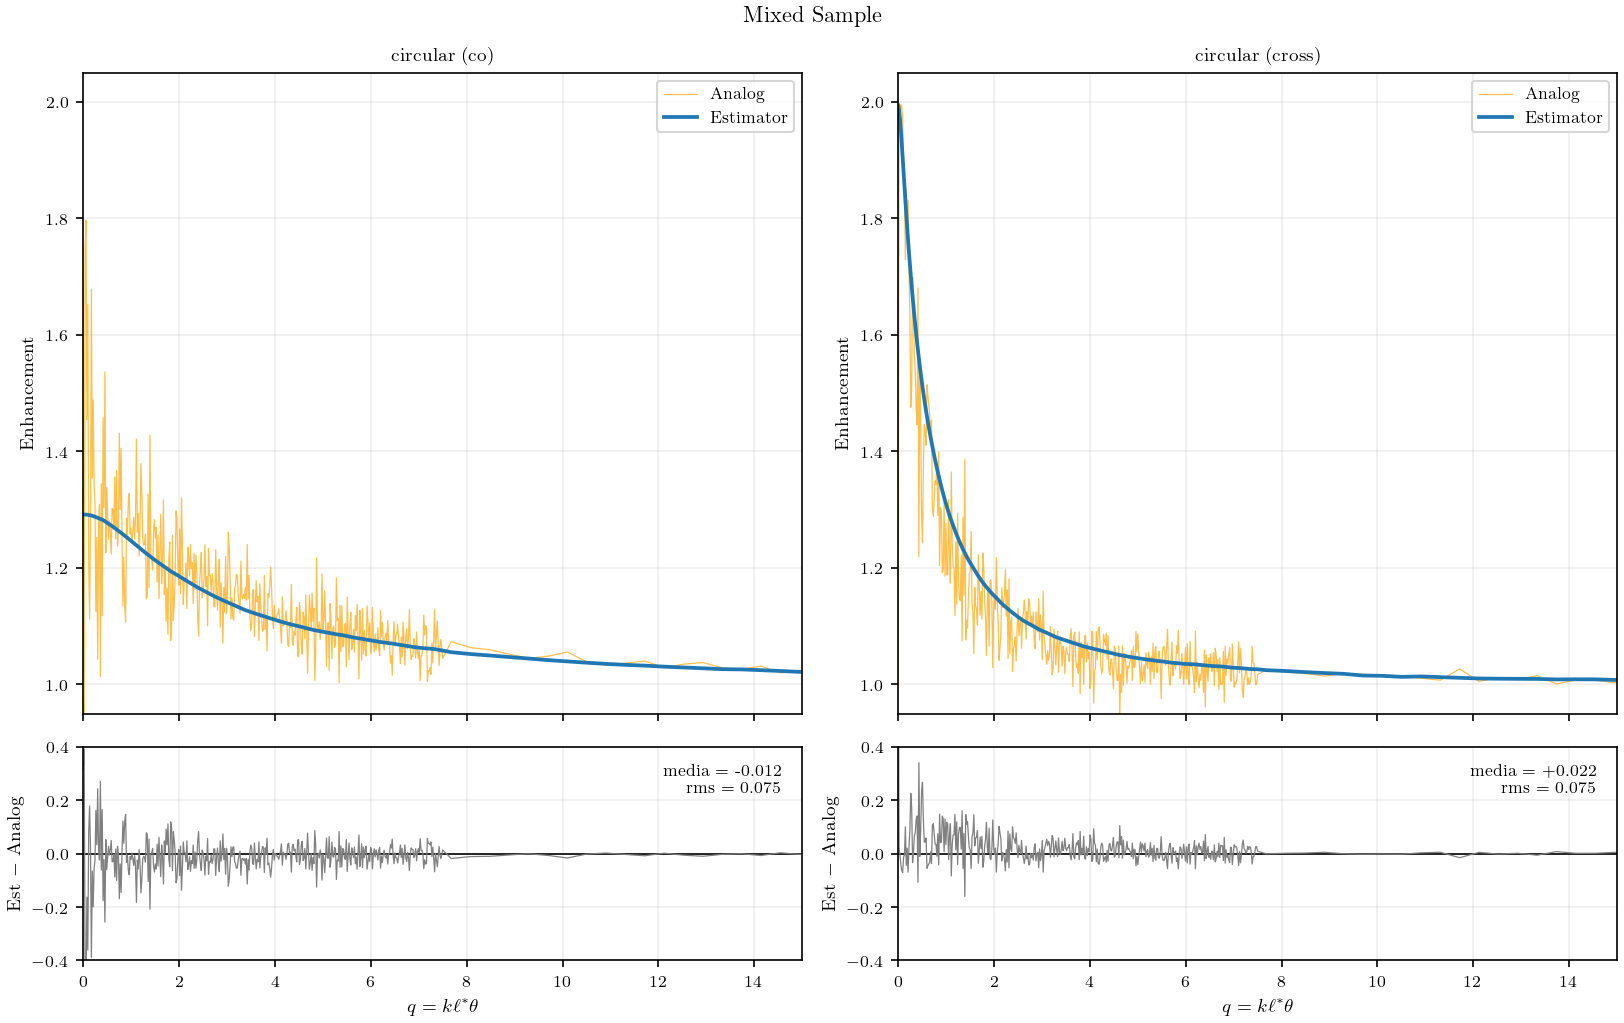

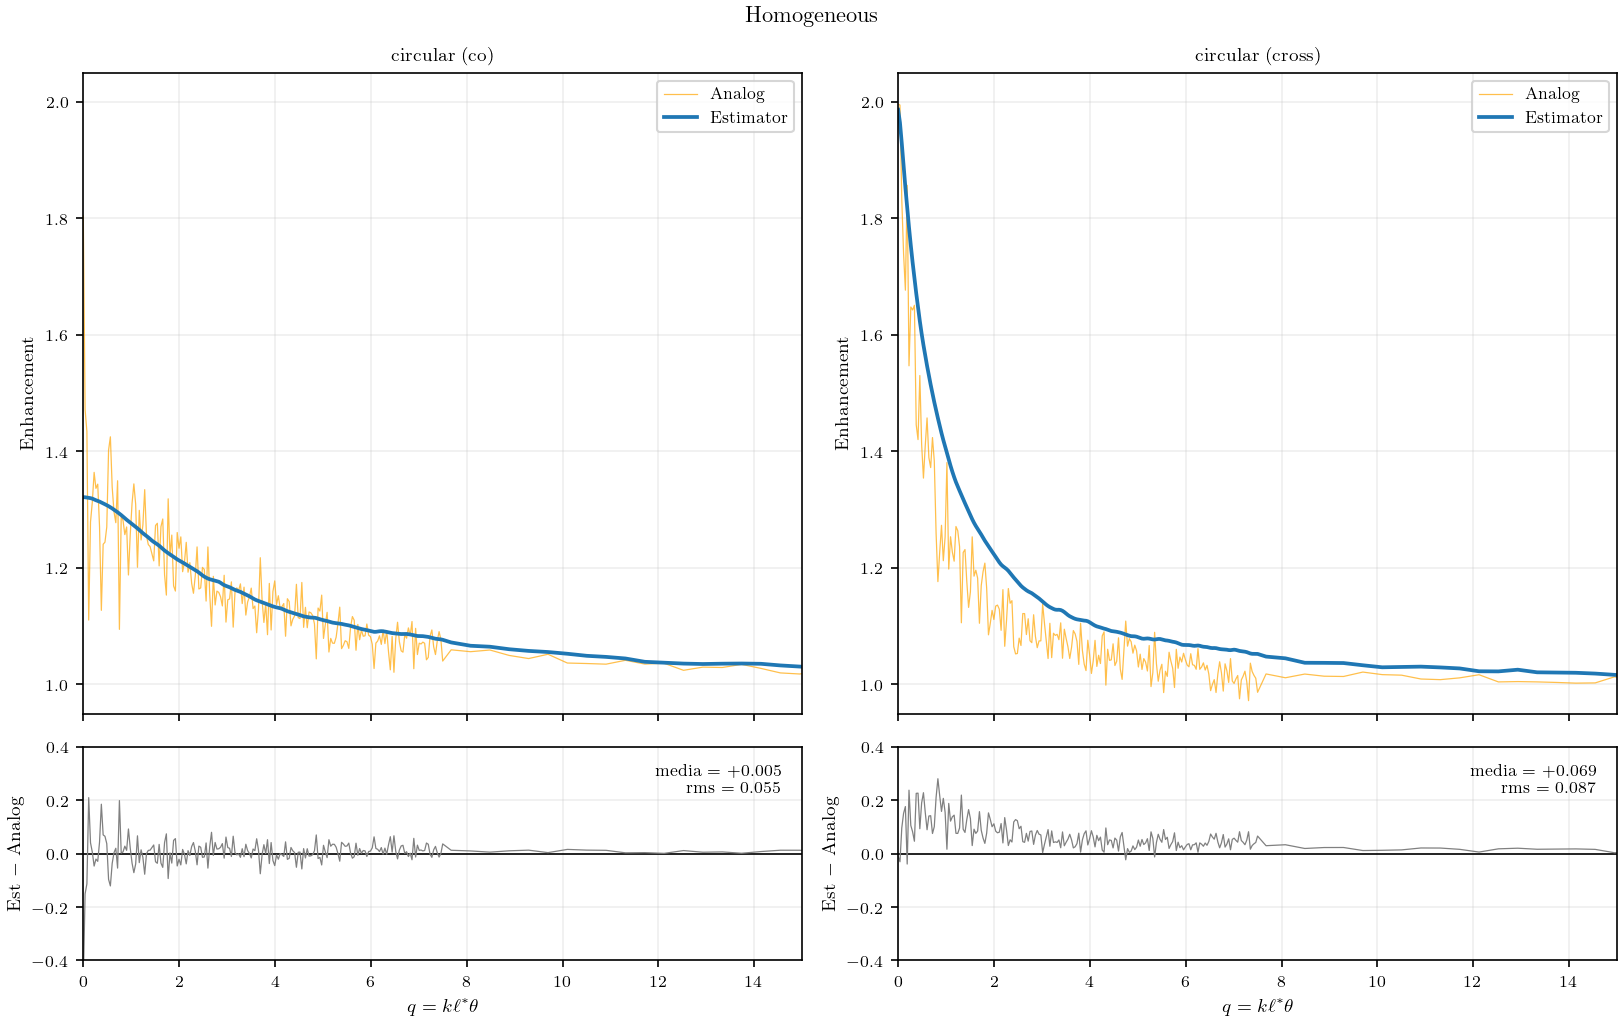

In [61]:
plot_estimator_vs_analog(sweep_mix, "Layered Sample", key_estimator_layer, key_analog_layer, "lstar_angle_anchor")
plot_estimator_vs_analog(sweep_mix, "Mixed Sample", key_estimator_mix, key_analog_mix, "lstar_mix")
plot_estimator_vs_analog(sweep_cbs, "Homogeneous", last_key_estimator, "0000_radius_0.055_analog_N1000000000_rep00", "transport_mean_free_path")